## Taxi Fare Prediction

### Problem Statement
The goal of this project is to predict the **total taxi fare amount (`total_amount`)** using trip-related features such as trip distance, passenger count, pickup time, location IDs, and additional surcharges.

This is a **supervised regression problem**, where the model learns the relationship between trip characteristics and the final fare charged.

### Dataset
The dataset contains taxi trip records including pickup/drop-off timestamps, distance traveled, passenger count, payment type, and additional fare components.

### Objective
Train machine learning models to accurately predict `total_amount` and compare their performance using evaluation metrics such as **R² Score** and **RMSE**.

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, RandomizedSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import xgboost as xgb
import seaborn as sns

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/mlp-term-1-2026-kaggle-assignment-1/sample_submission.csv
/kaggle/input/competitions/mlp-term-1-2026-kaggle-assignment-1/train.csv
/kaggle/input/competitions/mlp-term-1-2026-kaggle-assignment-1/test.csv


## Loading the Datasets

In [2]:
train_df = pd.read_csv('/kaggle/input/competitions/mlp-term-1-2026-kaggle-assignment-1/train.csv')
test_df = pd.read_csv('/kaggle/input/competitions/mlp-term-1-2026-kaggle-assignment-1/test.csv')

In [3]:
print(train_df.shape)
print(test_df.shape)

(10000, 17)
(1500, 17)


In [4]:
train_df.sample(7)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,extra,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
7817,1,2023-06-28 21:17:51,2023-06-28 22:54:01,4.0,4.23,1.0,N,258,150,Credit Card,1.0,4.002110,0.0,1.0,30.60,2.5,0.0
7628,0,2023-06-30 14:59:25,2023-06-30 15:55:17,2.0,1.10,1.0,N,196,121,Credit Card,2.5,4.973805,0.0,1.0,15.95,2.5,0.0
8043,1,2023-06-30 11:07:33,2023-06-30 10:43:50,1.0,1.93,1.0,N,195,207,Credit Card,0.0,5.888632,0.0,1.0,22.75,2.5,0.0
1674,1,2023-06-28 22:16:08,2023-06-28 23:43:58,2.0,0.94,1.0,N,87,73,Cash,1.0,3.562094,0.0,1.0,15.00,2.5,0.0
9317,1,2023-06-29 17:03:37,2023-06-29 18:23:42,1.0,1.42,1.0,N,94,122,Credit Card,2.5,4.938743,0.0,1.0,24.00,2.5,0.0
9348,1,2023-06-30 20:49:25,2023-06-30 22:20:21,1.0,1.29,1.0,N,149,247,Credit Card,1.0,1.889498,0.0,1.0,17.22,2.5,0.0
7444,1,2023-06-29 17:58:54,2023-06-29 18:46:12,1.0,1.66,1.0,N,129,49,Credit Card,2.5,4.717738,0.0,1.0,19.90,2.5,0.0


## Data types of Columns

In [5]:
# Information about datatypes of columns
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               10000 non-null  int64  
 1   tpep_pickup_datetime   10000 non-null  object 
 2   tpep_dropoff_datetime  10000 non-null  object 
 3   passenger_count        9634 non-null   float64
 4   trip_distance          10000 non-null  float64
 5   RatecodeID             9634 non-null   float64
 6   store_and_fwd_flag     9634 non-null   object 
 7   PULocationID           10000 non-null  int64  
 8   DOLocationID           10000 non-null  int64  
 9   payment_type           10000 non-null  object 
 10  extra                  10000 non-null  float64
 11  tip_amount             10000 non-null  float64
 12  tolls_amount           10000 non-null  float64
 13  improvement_surcharge  10000 non-null  float64
 14  total_amount           10000 non-null  float64
 15  con

### Convert Timestamps to correct Datatype

In [6]:
# Training Set
train_df['tpep_pickup_datetime'] = pd.to_datetime(train_df['tpep_pickup_datetime'])
train_df['tpep_dropoff_datetime'] = pd.to_datetime(train_df['tpep_dropoff_datetime'])
print(train_df[['tpep_pickup_datetime','tpep_dropoff_datetime']].dtypes)

# Test Set
test_df['tpep_pickup_datetime'] = pd.to_datetime(test_df['tpep_pickup_datetime'])
test_df['tpep_dropoff_datetime'] = pd.to_datetime(test_df['tpep_dropoff_datetime'])
print(test_df[['tpep_pickup_datetime','tpep_dropoff_datetime']].dtypes)

tpep_pickup_datetime     datetime64[ns]
tpep_dropoff_datetime    datetime64[ns]
dtype: object
tpep_pickup_datetime     datetime64[ns]
tpep_dropoff_datetime    datetime64[ns]
dtype: object


### Observations:

The dataset contains 10,000 records and 17 features.

Numerical Columns
- passenger_count  
- trip_distance  
- extra  
- tip_amount  
- tolls_amount  
- improvement_surcharge  
- congestion_surcharge  
- Airport_fee  

Categorical Columns
- payment_type  
- store_and_fwd_flag  

Additionally, some columns contain coded values that represent categories rather than true numerical quantities:
- VendorID  
- RatecodeID  
- PULocationID  
- DOLocationID  

Datetime Columns
- tpep_pickup_datetime  
- tpep_dropoff_datetime  

These columns were initially stored as object data types, but were converted to datetime format in the next step to enable time-based analysis.

Identifier Column
- VectorID  

This column uniquely identifies each record and does not contribute meaningful information for model training. It will be removed later during the feature selection stage.

## Descriptive Statistics of the Numerical Features

In [7]:
# Extracting numerical features
num_cols = train_df.select_dtypes(include = ['int64', 'float64']).columns

In [8]:
# Descriptive statistics matrix transpose
train_df[num_cols].describe().T  

,count,mean,std,min,25%,50%,75%,max
VendorID,10000.0,0.729100,0.444672,0.000000,0.000000,1.000000,1.000000,2.000000
passenger_count,9634.0,1.357276,0.883676,0.000000,1.000000,1.000000,1.000000,6.000000
trip_distance,10000.0,3.679527,4.905798,0.000000,1.070000,1.820000,3.630000,71.940000
RatecodeID,9634.0,1.450695,5.988978,1.000000,1.000000,1.000000,1.000000,99.000000
PULocationID,10000.0,132.710800,75.789597,1.000000,67.000000,133.000000,198.000000,264.000000
DOLocationID,10000.0,132.332400,75.959440,1.000000,68.000000,132.000000,199.000000,264.000000
extra,10000.0,1.940950,1.945885,-7.500000,0.000000,1.750000,2.500000,11.750000
tip_amount,10000.0,6.094658,4.438894,0.000713,3.466789,5.208233,7.455228,84.032617
tolls_amount,10000.0,0.664425,2.441070,-26.550000,0.000000,0.000000,0.000000,32.050000
improvement_surcharge,10000.0,0.979490,0.200076,-1.000000,1.000000,1.000000,1.000000,1.000000


### Observations:
* The maximum trip distance of 71.94 miles appears unusually large and may represent an outlier.
* The maximum trip amount of 84 suggests the presence of extreme values which will be further examined during outlier analysis.
* The presence of negative monetary values in some columns suggests possible refunds, corrections, or data entry issues. These will need to be investigated during the outlier detection stage.
* The minimum passenger count is 0, which is unusual and may represent missing or erroneous entries that should be examined later during data cleaning.
* Some columns have fewer observations than the total number of rows, indicating the presence of missing values.

## Feature Engineering


In [9]:
# Feature Engineering function, commonly applied to training and test sets
def make_features(df):
    df = df.copy()

    # Repair duration instead of dropping many rows
    df['trip_duration'] = (
        df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']
    ).dt.total_seconds().abs() / 60.0

    # Time features
    df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
    df['pickup_dayofweek'] = df['tpep_pickup_datetime'].dt.dayofweek
    df['pickup_month'] = df['tpep_pickup_datetime'].dt.month
    df['is_weekend'] = (df['pickup_dayofweek'] >= 5).astype(int)
    
    # Speed proxy
    df['speed_proxy'] = df['trip_distance'] / (df['trip_duration'] / 60.0 + 1e-3)

    # Known additive charge components
    known_cols = [
        'extra', 'tolls_amount', 'tip_amount', 
        'improvement_surcharge', 'congestion_surcharge', 'Airport_fee'
    ]
    df['known_charge_sum'] = df[known_cols].fillna(0).sum(axis=1)

    # Drop raw datetime columns after extracting useful features
    df = df.drop(columns=['tpep_pickup_datetime', 'tpep_dropoff_datetime'])
    return df

train_df = make_features(train_df)
test_df = make_features(test_df)

train_df.head()

,VendorID,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,extra,tip_amount,...,total_amount,congestion_surcharge,Airport_fee,trip_duration,pickup_hour,pickup_dayofweek,pickup_month,is_weekend,speed_proxy,known_charge_sum
0,0,1.0,1.50,1.0,N,212,237,Credit Card,5.0,6.533210,...,24.80,2.5,0.0,50.433333,17,2,6,0,1.782414,15.033210
1,0,1.0,3.80,1.0,N,6,163,Credit Card,5.0,9.187048,...,31.55,2.5,0.0,8.400000,19,3,6,0,26.950355,17.687048
2,1,2.0,1.89,1.0,N,35,81,Credit Card,2.5,6.793777,...,24.84,2.5,0.0,27.516667,18,4,6,0,4.112172,12.793777
3,1,1.0,1.10,1.0,N,46,99,Credit Card,1.0,3.695121,...,13.45,2.5,0.0,2.050000,22,4,6,0,31.279621,8.195121
4,1,2.0,2.84,1.0,N,213,114,Credit Card,2.5,7.838753,...,29.88,2.5,0.0,67.783333,18,2,6,0,2.511669,13.838753


In [10]:
# Extract categorical columns precisely
target = 'total_amount'
feature_cols = [c for c in train_df.columns if c not in [target]]

cat_cols = [
    'VendorID', 'RatecodeID', 'PULocationID', 'DOLocationID',
    'payment_type', 'store_and_fwd_flag', 
]
for c in cat_cols:
    train_df[c] = train_df[c].astype("category")
    test_df[c] = test_df[c].astype("category")

# Split features and targets
X = train_df[feature_cols]
y = train_df[target]
X_test = test_df[feature_cols]

print(X.shape, y.shape, X_test.shape)

(10000, 21) (10000,) (1500, 21)


Machine learning models cannot directly interpret raw datetime values, so several meaningful features were derived from the pickup and dropoff timestamps to better capture patterns in the data.

- **Trip Duration**: Calculated as the difference between dropoff and pickup time (in minutes). This represents the total duration of the trip and is a key factor influencing the total fare. Any negative durations (due to data inconsistencies) were handled by taking the **absolute value**, preserving the data instead of discarding it.

- **Pickup Hour**: Extracted from the pickup timestamp to capture variations in traffic conditions and demand throughout the day.

- **Pickup Day of Week**: Represents the day of the week (0–6), helping capture behavioral differences between weekdays and weekends.

- **Pickup Month**: Captures potential seasonal variations in travel patterns.

- **Is Weekend**: A binary feature indicating whether the trip occurred on a weekend, allowing the model to differentiate between weekday and weekend behavior.

- **Speed Proxy**: Estimated as trip distance divided by trip duration (converted to hours). This acts as a proxy for travel speed and helps identify unusually slow or fast trips.

- **Known Charge Sum**: Aggregates known additive fare components such as extra charges, tolls, tips, surcharges, and airport fees. This provides the model with a strong signal related to the final total amount.

To reduce the impact of extreme outliers, **trip duration** and **speed proxy** were clipped at the 99.5th percentile.

After extracting all relevant features, the original datetime columns were dropped, as they are no longer needed and cannot be directly used by machine learning models.

## Exploratory Data Analysis

In [11]:
num_cols

Index(['VendorID', 'passenger_count', 'trip_distance', 'RatecodeID',
       'PULocationID', 'DOLocationID', 'extra', 'tip_amount', 'tolls_amount',
       'improvement_surcharge', 'total_amount', 'congestion_surcharge',
       'Airport_fee'],
      dtype='object')

In [12]:
cat_cols

['VendorID',
 'RatecodeID',
 'PULocationID',
 'DOLocationID',
 'payment_type',
 'store_and_fwd_flag']

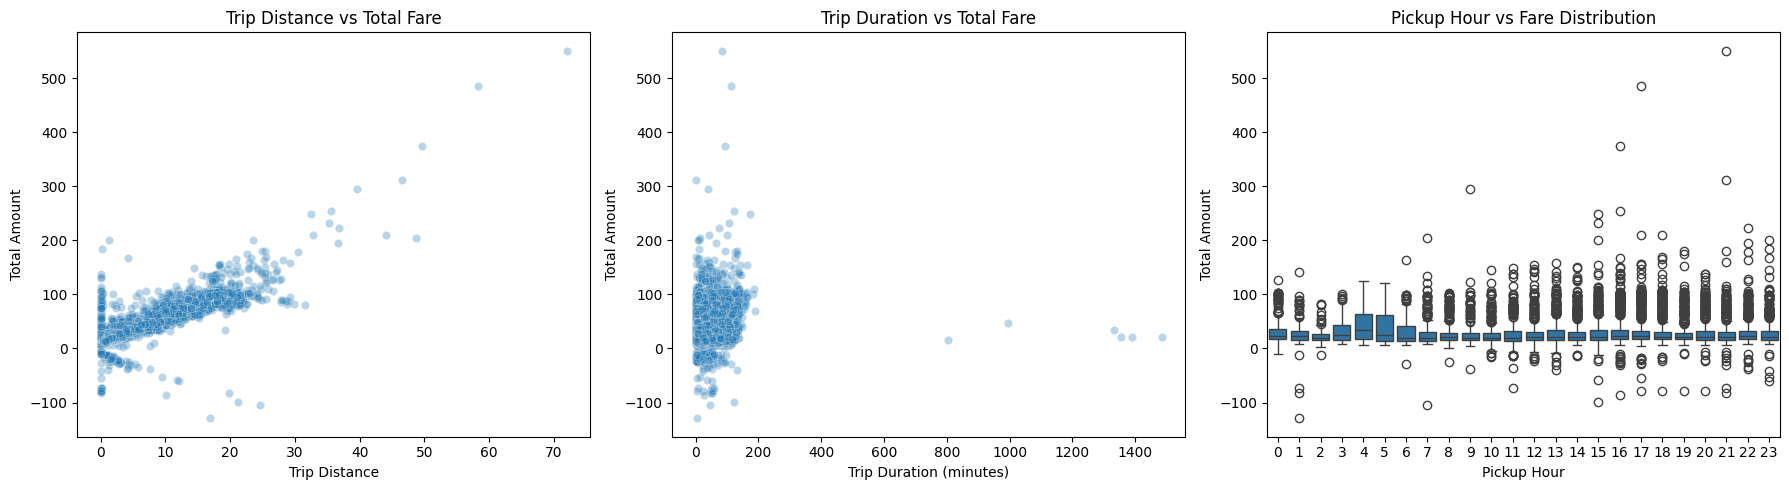

In [13]:
plt.figure(figsize=(18,5))

# 1. Trip Distance vs Total Fare
plt.subplot(1,3,1)
sns.scatterplot(x='trip_distance', y='total_amount', data=train_df, alpha=0.3)
plt.title("Trip Distance vs Total Fare")
plt.xlabel("Trip Distance")
plt.ylabel("Total Amount")

# 2. Trip Duration vs Total Fare
plt.subplot(1,3,2)
sns.scatterplot(x='trip_duration', y='total_amount', data=train_df, alpha=0.3)
plt.title("Trip Duration vs Total Fare")
plt.xlabel("Trip Duration (minutes)")
plt.ylabel("Total Amount")

# 3. Pickup Hour vs Fare
plt.subplot(1,3,3)
sns.boxplot(x='pickup_hour', y='total_amount', data=train_df)
plt.title("Pickup Hour vs Fare Distribution")
plt.xlabel("Pickup Hour")
plt.ylabel("Total Amount")

plt.tight_layout()
plt.show()

### Visual Analysis

To better understand the relationship between features and the target variable (**total_amount**), several visualizations were created.

---

### 1. Trip Distance vs Total Fare

This scatter plot shows a **clear positive relationship** between trip distance and total fare.

- As the trip distance increases, the total fare also increases.
- The relationship is roughly linear, which makes sense since taxi fares are distance-based.
- Some extreme values (very high fares) are visible, indicating the presence of **outliers**.

This confirms that **trip distance is one of the most important features** for predicting fare.

---

### 2. Trip Duration vs Total Fare

This scatter plot shows a **weaker relationship** compared to trip distance.

- While longer trips tend to have higher fares, the pattern is more scattered.
- This is because duration is affected by traffic, signals, and waiting time, not just distance.
- There are also some unusual values (very long duration but moderate fare), indicating noise or inconsistencies.

Trip duration is still useful, but **less reliable than distance alone**.

---

### 3. Pickup Hour vs Fare Distribution

This boxplot shows how fares vary across different hours of the day.

- The median fare remains fairly consistent across most hours.
- However, some hours show more variability and outliers (especially late evening/night).
- This suggests that time of day has **some influence**, but not as strong as distance.

Time-based features help capture patterns like traffic and demand, but are **secondary features**.

---

### Overall Insight

- Trip Distance is the strongest predictor of fare.
- Trip Duration adds useful but noisy information.
- Pickup Time features capture behavioral patterns but have smaller impact.

These observations support the use of **tree-based models**, which can effectively capture both linear and non-linear relationships in the data.

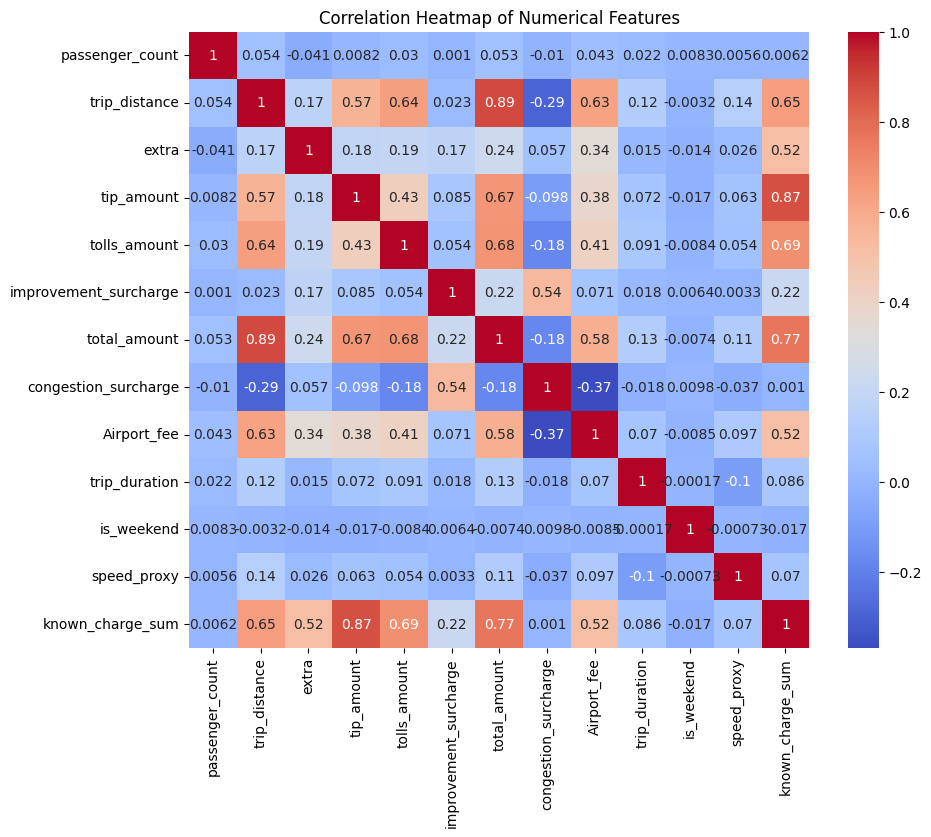

In [14]:
# Correlation Heatmap
num_cols = train_df.select_dtypes(include=['int64','float64']).columns
plt.figure(figsize=(10,8))
sns.heatmap(train_df[num_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

### Correlation Heatmap Inferences

- **Trip Distance (0.89)**  
  → Strongest driver of total fare  
  → Confirms fare mainly depends on distance  

- **Known Charge Sum (0.77)**  
  → Highly correlated with total fare  
  → Logical since it includes fare components (tips, tolls, etc.)

- **Tip Amount (0.67) & Tolls Amount (0.68)**  
  → Significant contributors to the final amount  

- **Airport Fee (0.58)**  
  → Airport trips generally have higher fares  


### Important Observation

- **Trip Duration (0.17)**  
  → Much weaker than distance  
  → Distance is a better predictor than time  


### Final Takeaway

The fare is primarily influenced by:
- **Trip Distance**
- **Additional Charges (tips, tolls, fees)**

Other features have relatively smaller impact.

These relationships help confirm that the selected features are meaningful predictors for the machine learning models used later in the analysis.

## Train / Validation Split

In [15]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size = 0.2, random_state = 42)

## Detecting and Handling Missing Values

In [16]:
# Extracting numerical columns for imputation (from X_train, without the target and known sum column, to avoid leakage)
num_cols = [
    c for c in X_train.select_dtypes(include=['int64','float64']).columns
    if c not in ['total_amount', 'known_charge_sum']
]

In [17]:
# Total no.of missing values
print('Total no.of missing values is',train_df.isna().sum().sum())

# No.of missing values in each feature
train_df.isna().sum().sort_values(ascending=False)

Total no.of missing values is 1830


passenger_count          366
RatecodeID               366
store_and_fwd_flag       366
congestion_surcharge     366
Airport_fee              366
VendorID                   0
PULocationID               0
trip_distance              0
extra                      0
DOLocationID               0
tip_amount                 0
tolls_amount               0
improvement_surcharge      0
payment_type               0
total_amount               0
trip_duration              0
pickup_hour                0
pickup_dayofweek           0
pickup_month               0
is_weekend                 0
speed_proxy                0
known_charge_sum           0
dtype: int64

In [18]:
num_imputer = SimpleImputer(strategy = 'mean')
cat_imputer = SimpleImputer(strategy = 'most_frequent')

# Numerical features imputed with Mean
num_imputer.fit(X_train[num_cols])
X_train[num_cols] = num_imputer.transform(X_train[num_cols])
X_val[num_cols] = num_imputer.transform(X_val[num_cols])
test_df[num_cols] = num_imputer.transform(test_df[num_cols])

# Categorical features imputed with Mode
cat_imputer.fit(X_train[cat_cols])
X_train[cat_cols] = cat_imputer.transform(X_train[cat_cols])
X_val[cat_cols] = cat_imputer.transform(X_val[cat_cols])
test_df[cat_cols] = cat_imputer.transform(test_df[cat_cols])

print(X_train.isna().sum()[X_train.isna().sum() > 0])

Series([], dtype: int64)


### Missing Value Handling

The dataset was checked for missing values, and a total of **1830 missing entries** were identified. The affected columns were:

- passenger_count  
- RatecodeID  
- store_and_fwd_flag  
- congestion_surcharge  
- Airport_fee  

To handle missing values, **SimpleImputer** was used.

- For **numerical columns**, missing values were replaced with the **mean** of the column. This helps preserve the overall distribution without introducing bias.

- For **categorical columns**, missing values were replaced with the **most frequent value (mode)**, ensuring that valid category information is maintained.

The imputers were **fit only on the training data** and then applied to the validation and test sets. This prevents data leakage and ensures consistent preprocessing across all datasets.

After imputation, no missing values remained in the dataset, and the data was ready for further processing.

## Detecting and Dropping Duplicates

In [19]:
# Count no.of duplicate values
print('No.of duplicates is', train_df.duplicated().sum()) 

No.of duplicates is 0


No duplicate values were found in the train dataset.

## Detecting and Handling Outliers

In [20]:
outlier_info = {}
for feature in num_cols:
    q25 = X_train[feature].quantile(0.25)
    q75 = X_train[feature].quantile(0.75)
    iqr = q75 - q25
    lower_bound = q25 - iqr * 1.5
    upper_bound = q75 + iqr * 1.5
    outliers = X_train[(X_train[feature] < lower_bound ) | (X_train[feature] > upper_bound)]
    
    outlier_info[feature] = {'count': len(outliers), 'indices': list(outliers.index)}

    print(feature,':',outlier_info[feature]['count'])

passenger_count : 1887
trip_distance : 1083
extra : 192
tip_amount : 524
tolls_amount : 725
improvement_surcharge : 82
congestion_surcharge : 1051
Airport_fee : 1011
trip_duration : 70
is_weekend : 32
speed_proxy : 938


### IQR-Based Capping

In [21]:
X_train = X_train.copy()
X_val = X_val.copy()
X_test = X_test.copy()

# Calculating the 99.5th percentile for clipping
dur_cap = X_train['trip_duration'].quantile(0.995)
speed_cap = X_train['speed_proxy'].quantile(0.995)

# Train
X_train['trip_duration'] = X_train['trip_duration'].clip(0, dur_cap)
X_train['speed_proxy'] = X_train['speed_proxy'].clip(0, speed_cap)

# Validation
X_val['trip_duration'] = X_val['trip_duration'].clip(0, dur_cap)
X_val['speed_proxy'] = X_val['speed_proxy'].clip(0, speed_cap)

# Test
X_test['trip_duration'] = X_test['trip_duration'].clip(0, dur_cap)
X_test['speed_proxy'] = X_test['speed_proxy'].clip(0, speed_cap)

### Outlier Handling

Outliers in numerical features were detected using the Interquartile Range (IQR) method. Several features such as `trip_distance`, `tip_amount`, and `total_amount` showed a significant number of outliers.

However, not all outliers were treated in the same way.

- Features like **tip_amount, tolls_amount, and Airport_fee** can naturally have high values depending on the trip and are part of the actual fare calculation. Therefore, these values were retained to preserve real-world variability.

- On the other hand, derived features such as **trip_duration** and **speed_proxy** showed extreme values likely caused by data inconsistencies (e.g., incorrect timestamps or very small durations leading to unrealistic speeds).

To handle this, these features were **clipped at the 99.5th percentile**, reducing the impact of extreme values while retaining most of the data.
Clipping thresholds were computed using the training data and applied consistently to validation and test sets to prevent data leakage.

This approach ensures that meaningful variations are preserved while limiting the influence of unrealistic values.


## Encoding Categorical Variables

In [22]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8000 entries, 9254 to 7270
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               8000 non-null   object 
 1   passenger_count        8000 non-null   float64
 2   trip_distance          8000 non-null   float64
 3   RatecodeID             8000 non-null   object 
 4   store_and_fwd_flag     8000 non-null   object 
 5   PULocationID           8000 non-null   object 
 6   DOLocationID           8000 non-null   object 
 7   payment_type           8000 non-null   object 
 8   extra                  8000 non-null   float64
 9   tip_amount             8000 non-null   float64
 10  tolls_amount           8000 non-null   float64
 11  improvement_surcharge  8000 non-null   float64
 12  congestion_surcharge   8000 non-null   float64
 13  Airport_fee            8000 non-null   float64
 14  trip_duration          8000 non-null   float64
 15  pickup

In [23]:
# Count of each category
print(X_train['payment_type'].value_counts())
print(X_train['store_and_fwd_flag'].value_counts())

payment_type
Credit Card    6195
Cash           1357
Wallet          290
unknown         106
UPI              52
Name: count, dtype: int64
store_and_fwd_flag
N    7942
Y      58
Name: count, dtype: int64


In [24]:
# Copy original datasets
X_train_enc = X_train.copy()
X_val_enc = X_val.copy()
X_test_enc = test_df.copy()

# Label encode binary column
le = LabelEncoder()

X_train_enc['store_and_fwd_flag'] = le.fit_transform(X_train_enc['store_and_fwd_flag'])
X_val_enc['store_and_fwd_flag'] = le.transform(X_val_enc['store_and_fwd_flag'])
X_test_enc['store_and_fwd_flag'] = le.transform(X_test_enc['store_and_fwd_flag'])

# One-hot encoding
X_train_enc = pd.get_dummies(X_train_enc, columns=cat_cols, drop_first=True)
X_val_enc = pd.get_dummies(X_val_enc, columns=cat_cols, drop_first=True)
X_test_enc = pd.get_dummies(X_test_enc, columns=cat_cols, drop_first=True)

# Align columns
X_train_enc, X_val_enc = X_train_enc.align(X_val_enc, join='left', axis=1, fill_value=0)
X_train_enc, X_test_enc = X_train_enc.align(X_test_enc, join='left', axis=1, fill_value=0)

### Reasoning

- The dataset contains several categorical features such as **VendorID, RatecodeID, store_and_fwd_flag, PULocationID, DOLocationID, and payment_type**. Since most machine learning algorithms require numerical inputs, these categorical variables were encoded before model training.

- The store_and_fwd_flag feature contains only two possible values: **Y** and **N**. Therefore, **Label Encoding** is appropriate for this variable. The values are converted into numerical form by mapping Y → 1 and N → 0. This encoding preserves the binary nature of the feature and avoids creating unnecessary additional columns.

- The remaining categorical variables (VendorID, RatecodeID, PULocationID, DOLocationID, and payment_type) contain **multiple categories** without any inherent ordering. Therefore, **One-Hot Encoding** was used for these features. One-hot encoding creates separate binary columns for each category, allowing the model to treat them as independent categories rather than assuming any ordinal relationship.

- To maintain consistency, the same encoding transformations are applied to both the training and test datasets. They are first fit on the training set and then applied to both the datasets.

## Scaling Numerical Features

In [25]:
X_train_enc['known_charge_sum'] = X_train['known_charge_sum'].values
X_val_enc['known_charge_sum'] = X_val['known_charge_sum'].values
X_test_enc['known_charge_sum'] = test_df['known_charge_sum'].values

In [26]:
# Copy encoded datasets
X_train_sc = X_train_enc.copy()
X_val_sc = X_val_enc.copy()
X_test_sc = X_test_enc.copy()

# Fit StandardScaler on train set, and transform train, validation and test tests.
sc = StandardScaler()

X_train_sc[num_cols] = sc.fit_transform(X_train_sc[num_cols])
X_val_sc[num_cols] = sc.transform(X_val_sc[num_cols])
X_test_sc[num_cols] = sc.transform(X_test_sc[num_cols])

Target y is not scaled because then, the predictions would come out in scaled units.

### Reasoning

- Feature scaling is applied to numerical variables to normalize them to similar ranges. This helps many machine learning algorithms converge faster and prevents features with large magnitudes from dominating the model.

- The following numerical features either have largely varying ranges or represent continuous values such as monetary amounts and therefore require scaling:

  trip_distance, extra, tip_amount, tolls_amount, improvement_surcharge, congestion_surcharge, Airport_fee, trip_duration.

- The **StandardScaler** method is used for scaling. StandardScaler standardizes features by transforming them so that they have a mean of 0 and a standard deviation of 1, according to the formula:
$$
z = \frac{x - \mu}{\sigma}
$$
    where
    $x$ = original value,
    $\mu$ = mean of the feature,
    $\sigma$ = standard deviation of the feature

- The scaler is fit on the training data and then applied to both the training and test datasets to ensure consistent scaling.

## Training Base Models 

In [28]:
# Prepare targets

y_train_total = train_df.loc[X_train.index, "total_amount"]
y_val_total = train_df.loc[X_val.index, "total_amount"]

X_test_enc['known_charge_sum'] = test_df['known_charge_sum'].values

## Linear Regressor

In [29]:
lr = LinearRegression()

# Fit lr on scaled X_train and y_train
lr.fit(X_train_sc, y_train_total)

# Use the fit and predict on scaled validation set
lr_pred_total = lr.predict(X_val_sc)

# Evaluate the prediction using R2_score
print("Linear Regression R2:", r2_score(y_val_total, lr_pred_total))

Linear Regression R2: 0.8549358086951782


## Ridge Regressor

In [30]:
ridge = Ridge()
ridge.fit(X_train_sc, y_train_total)
ridge_pred_total = ridge.predict(X_val_sc)
print("Ridge R2:", r2_score(y_val_total, ridge_pred_total))

Ridge R2: 0.8552307648023825


## Lasso Regressor

In [31]:
lasso = Lasso()
lasso.fit(X_train_sc, y_train_total)
lasso_pred_total = lasso.predict(X_val_sc)
print("Lasso R2:", r2_score(y_val_total, lasso_pred_total))

Lasso R2: 0.8121981373461955


## KNN Regressor

In [32]:
knn = KNeighborsRegressor()
knn.fit(X_train_sc, y_train_total)
knn_pred_total = knn.predict(X_val_sc)
print("KNN R2:", r2_score(y_val_total, knn_pred_total))

KNN R2: 0.7493539739884343


## Decision Tree Regressor

In [33]:
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train_enc, y_train_total)
dt_pred_total = dt.predict(X_val_enc)
print("Decision Tree R2:", r2_score(y_val_total, dt_pred_total))

Decision Tree R2: 0.8695210950649295


## Random Forest Regressor

In [34]:
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train_enc, y_train_total)
rf_pred_total = rf.predict(X_val_enc)
print("Random Forest R2:", r2_score(y_val_total, rf_pred_total))

Random Forest R2: 0.9041961580111049


## Gradient Boosting Regressor

In [35]:
gb = GradientBoostingRegressor(random_state=42)
gb.fit(X_train_enc, y_train_total)
gb_pred_total = gb.predict(X_val_enc)
print("Gradient Boosting R2:", r2_score(y_val_total, gb_pred_total))

Gradient Boosting R2: 0.9052313444665736


## XGBoost Regressor

In [36]:
xgb_base = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)
xgb_base.fit(X_train_enc, y_train_total)
xgb_pred_total = xgb_base.predict(X_val_enc)
rmse_xgb = np.sqrt(mean_squared_error(y_val_total, xgb_pred_total))
print("XGBoost RMSE:", rmse_xgb)
print("XGBoost R2:", r2_score(y_val_total, xgb_pred_total))

XGBoost RMSE: 10.061474503259864
XGBoost R2: 0.8622352425797536


### Observations
Multiple regression models were trained on the processed dataset and evaluated on the validation set using **RMSE** and **R² score**. The purpose of training several models was to identify which algorithms capture the relationship between the features and the target variable (**total_amount**) most effectively.

Among the models tested, **Decision Tree Regressor**, **XGBoost Regressor**, and **Gradient Boosting Regressor** achieved the highest validation performance and were therefore selected for further hyperparameter tuning.

1. Tree-based models performed particularly well because they can capture **non-linear relationships and interactions between features**, which are common in taxi fare datasets. 

    - Gradient Boosting builds trees sequentially, where each new tree attempts to correct the errors of the previous trees, allowing the model to learn complex patterns.

    - Decision Trees are highly sensitive to hyperparameters such as depth and minimum samples, and tuning these parameters can significantly improve performance.

2. **XGBoost Regressor** also showed strong performance. XGBoost is an optimized gradient boosting algorithm known for its speed and accuracy on tabular datasets. It uses regularization terms (L1 and L2) directly in its objective function, which helps prevent overfitting and often leads to superior generalization compared to standard Gradient Boosting.

3. KNN performed significantly worse than the other models, indicating that instance-based methods may not be suitable for this dataset.

Hyperparameter tuning was performed on the selected models using **GridSearchCV** for Decision Tree and Gradient Boosting, and **RandomizedSearchCV** for XGBoost to efficiently explore a wider parameter space.

## Hyperparameter Tuning

In [37]:
# Define hyperparameter search space for Gradient Boosting

gb_params = {
    'n_estimators': [200, 300, 400],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'subsample': [0.8, 1.0]
}

# GridSearchCV used for efficient hyperparameter tuning
gb_grid = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    gb_params,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

# Fit on training data to find best hyperparameters
gb_grid.fit(X_train_enc, y_train_total)
best_gb = gb_grid.best_estimator_

# Evaluate on held-out validation set
gb_pred_total = best_gb.predict(X_val_enc)

rmse_gb = np.sqrt(mean_squared_error(y_val_total, gb_pred_total))
r2_gb = r2_score(y_val_total, gb_pred_total)

print("Best Gradient Boosting Parameters:", gb_grid.best_params_)
print("Gradient Boosting RMSE:", rmse_gb)
print("Gradient Boosting R2:", r2_gb)

Best Gradient Boosting Parameters: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 400, 'subsample': 0.8}
Gradient Boosting RMSE: 8.548538039007234
Gradient Boosting R2: 0.9005514244404131


In [38]:
# Define 5-fold cross-validation strategy with shuffling for better generalization
cv_strategy = KFold(n_splits=5, shuffle=True, random_state=42)

# Define hyperparameter search space for XGBoost
param_dist = {
    'n_estimators': [100, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7, 9],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'subsample': [0.7, 0.8, 1.0]
}

# RandomizedSearchCV is used for efficient hyperparameter tuning over large search space
xgb_search = RandomizedSearchCV(
    xgb.XGBRegressor(objective='reg:squarederror', random_state=42),
    param_distributions=param_dist,
    n_iter=15,
    cv=cv_strategy,
    scoring='r2',
    n_jobs=-1,
    random_state=42
)

# Fit on training data to find best hyperparameters
xgb_search.fit(X_train_enc, y_train_total)
best_params = xgb_search.best_params_
print("Best XGBoost Parameters:", best_params)

# Prepare full training data for manual K-Fold evaluation
X_full = X_train_enc
y_full = y_train_total

# Initialize model with best parameters
best_xgb = xgb.XGBRegressor(**best_params, objective='reg:squarederror', random_state=42)

oof_predictions = np.zeros(len(X_full))
test_predictions = np.zeros(len(X_test_enc))

train_r2_scores = []
val_r2_scores = []

# Perform manual K-Fold training for OOF evaluation
for fold, (train_idx, val_idx) in enumerate(cv_strategy.split(X_full)):

    # Split data into training and validation folds
    X_tr, y_tr = X_full.iloc[train_idx], y_full.iloc[train_idx]
    X_vl, y_vl = X_full.iloc[val_idx], y_full.iloc[val_idx]

    # Train model on current fold
    best_xgb.fit(X_tr, y_tr)
    
    train_preds = best_xgb.predict(X_tr)
    val_preds = best_xgb.predict(X_vl)
    
    oof_predictions[val_idx] = val_preds
    test_predictions += best_xgb.predict(X_test_enc) / cv_strategy.get_n_splits()
    
    train_r2_scores.append(r2_score(y_tr, train_preds))
    val_r2_scores.append(r2_score(y_vl, val_preds))
    
# Average validation R² across folds (cross-validation performance)
print(f"Average Val R2: {np.mean(val_r2_scores):.4f}")

# OOF R² gives reliable estimate of generalization performance
print(f"Overall OOF R2: {r2_score(y_full, oof_predictions):.4f}")

# Best model from RandomizedSearchCV
best_xgb_model = xgb_search.best_estimator_

# Evaluate on held-out validation set (used for final comparison)
xgb_pred_total = best_xgb_model.predict(X_val_enc)
rmse_xgb = np.sqrt(mean_squared_error(y_val_total, xgb_pred_total))
r2_xgb = r2_score(y_val_total, xgb_pred_total)

print("XGBoost RMSE:", rmse_xgb)
print("XGBoost R2:", r2_xgb)

Best XGBoost Parameters: {'subsample': 0.7, 'n_estimators': 500, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
Average Val R2: 0.9259
Overall OOF R2: 0.9246
XGBoost RMSE: 8.791844383687783
XGBoost R2: 0.8948099032091767


In [39]:
# Define hyperparameter search space for Decision Tree Regressor
dt_params = {
    'max_depth': [5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5]
}

# GridSearchCV use for hyperparameter tuning
dt_grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    dt_params,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

# Fit on training data to find best hyperparameters
dt_grid.fit(X_train_enc, y_train_total)
best_dt = dt_grid.best_estimator_

# Evaluate on held-out validation set
dt_pred_total = best_dt.predict(X_val_enc)

rmse_dt = np.sqrt(mean_squared_error(y_val_total, dt_pred_total))
r2_dt = r2_score(y_val_total, dt_pred_total)

print("Best Decision Tree Parameters:", dt_grid.best_params_)
print("Decision Tree RMSE:", rmse_dt)
print("Decision Tree R2:", r2_dt)

Best Decision Tree Parameters: {'max_depth': 15, 'min_samples_leaf': 2, 'min_samples_split': 10}
Decision Tree RMSE: 7.168967321003184
Decision Tree R2: 0.9300596065253728


In [42]:
# Model Comaprison

results_df = pd.DataFrame({
    "Model": ["Decision Tree", "Gradient Boosting","XGBoosting"],
    "R2 Score": [r2_dt, r2_gb, r2_xgb],
    "RMSE": [rmse_dt, rmse_gb, rmse_xgb]
})

results_df

,Model,R2 Score,RMSE
0,Decision Tree,0.930060,7.168967
1,Gradient Boosting,0.900551,8.548538
2,XGBoosting,0.894810,8.791844


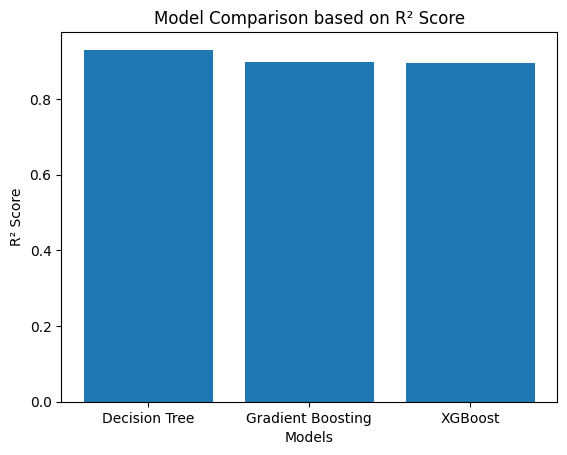

In [43]:
# Graph Comparison of tuned Models

models = ['Decision Tree', 'Gradient Boosting', 'XGBoost']
r2_scores = [0.93, 0.898, 0.896]  # replace with your exact values if needed

plt.figure()
plt.bar(models, r2_scores)

plt.xlabel("Models")
plt.ylabel("R² Score")
plt.title("Model Comparison based on R² Score")

plt.show()

After performing hyperparameter tuning and evaluating the models, the models were compared using **R² score and RMSE**.

Among the tuned models, **Decision Tree Regressor**, **XGBoost Regressor**, and **Gradient Boosting Regressor** showed strong performance. The **Decision Tree Regressor achieved the highest R² score on the validation dataset**, indicating strong predictive performance on the given split.

Although XGBoost demonstrated more consistent performance across cross-validation, the Decision Tree model produced the best validation result and was therefore selected as the final model for this task.

## Final Model Selection

In [40]:
# Predictions on final test set
final_predictions = best_dt.predict(X_test_enc)

In [41]:
# Creating submission.csv

sample_submission = pd.read_csv(
    "/kaggle/input/competitions/mlp-term-1-2026-kaggle-assignment-1/sample_submission.csv"
)

sample_submission["total_amount"] = final_predictions

sample_submission.to_csv("submission.csv", index=False)

sample_submission.head()

,id,total_amount
0,0,18.475556
1,1,27.730263
2,2,26.848182
3,3,17.930000
4,4,14.907500


### Conclusion

The selected model was then used to predict `total_amount` for the test dataset, and the predictions were formatted according to the competition’s submission requirements.